# Sales Forecasting for Retail Decision-Making  
## A Business Intelligence Case Study Using Walmart Sales Data  

**Module:** Business Intelligence and Data Mining (UFCFMM)  
**Assessment:** Group Project Portfolio  
**Team Members:** [Daniel Shipton, Samuel Fitzgerald, Nifemi Omoshuli]  
**Dataset Source:** Kaggle – Walmart Sales Dataset  

---

## Executive Summary 

## 1. Problem Definition & Strategic Scoping 

### 1.1 Strategic Scoping 

Walmart is a large-scale retail organisation that operates within a highly competitive and low-margin market where operational efficiency and demand responsiveness is key to lasting profitability. Sales forecasting is a strategic asset that underpins inventory management, workforce allocation, supply chain coordination, promotional planning and financial forecasting.  

An inaccurate financial forecast can cause substantial operational inefficiencies. An overwhelming amount of demands will lead to overstocking, an increased holding cost, markdown losses and waste products. Also, undermining the forecast can lead to stockouts, lost revenue and loss of customer satisfaction. In short, even small forecasting errors can turn into a significant financial impact especially when aggregated across department across department and regions.  

The retail demand is influenced by multiple factors. 

1) Seasonal change (Holiday periods)  

2) Unemployment inflation. 

3) External costs (Fuel prices. The higher the cost of fuel the less amount the customer will spend.)  

4) Local store Intelligence  

A competent business intelligent system will be able to identify the demand drivers and will be able to produce reliable forecast and provide a competitive advantage. 


### 1.2 Business Problem Statement 

This project will address the following problem how can historical weekly sales data across Walmart stores be analysed for firstly the forecast future sales with acceptable predictive accuracy. Secondly, identify the key structure and the economic factors that would influence the sales variability therefor enabling data driven operational planning  

The problem is divided into two different sections.  

1) Predictive dimensions (Generating the forward looking sales forecast)  

2) Diagnostic dimensions (Understand what drives sales variation)  

By combing thee forecasting with explanatory analysis they will move beyond technical modelling and towards actionable business intelligence, aligning directly with the learning outcomes of investigating real-world applications of data mining in business contexts 

## 2. Technical Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


df = pd.read_csv("Walmart.csv")
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)


weekly_total = (
    df.groupby('Date', as_index=False)
    .agg({
        'Weekly_Sales': 'sum',
        'Holiday_Flag': 'max',
        'Temperature': 'mean',
        'Fuel_Price': 'mean',
        'CPI': 'mean',
        'Unemployment': 'mean'
    })
    .sort_values('Date')
    .reset_index(drop=True)
)


weekly_total['Month'] = weekly_total['Date'].dt.month
weekly_total['Year'] = weekly_total['Date'].dt.year
weekly_total['Week'] = weekly_total['Date'].dt.isocalendar().week.astype(int)

weekly_total['Rolling_4wk'] = weekly_total['Weekly_Sales'].rolling(window=4).mean()
weekly_total['Lag_1'] = weekly_total['Weekly_Sales'].shift(1)
weekly_total['Lag_2'] = weekly_total['Weekly_Sales'].shift(2)
weekly_total['Lag_4'] = weekly_total['Weekly_Sales'].shift(4)
weekly_total['Lag_12'] = weekly_total['Weekly_Sales'].shift(12)

weekly_total['Time_Index'] = range(len(weekly_total))

# Drop NA from lag/rolling
weekly_total = weekly_total.dropna().reset_index(drop=True)

# Features
features = ["Lag_1", "Lag_2", "Rolling_4wk", "Time_Index", "Month"]

X = weekly_total[features]
y = weekly_total["Weekly_Sales"]

# Train/test split
split = int(len(X) * 0.8)
X_train = X.iloc[:split]
X_test = X.iloc[split:]
y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("Setup complete")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Setup complete
Training samples: 104
Testing samples: 27


In [2]:
# =========================
# MASTER MODEL CELL — RUN FIRST
# =========================

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor

# -------------------------
# Random Forest
# -------------------------
rf_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# -------------------------
# Gradient Boosting
# -------------------------
gbr_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gbr_model.fit(X_train, y_train)
y_pred_gbr = gbr_model.predict(X_test)

# -------------------------
# Decision Tree (baseline non-linear)
# -------------------------
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

# -------------------------
# MLP Neural Network (scaled X & y)
# -------------------------
mlp_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(100, 50),
        max_iter=3000,
        early_stopping=True,
        random_state=42
    ))
])

mlp_model = TransformedTargetRegressor(
    regressor=mlp_pipeline,
    transformer=StandardScaler()
)

mlp_model.fit(X_train, y_train)
y_pred_mlp = mlp_model.predict(X_test)

# -------------------------
# SVR (scaled X & y)
# -------------------------
svr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf", C=1000, gamma=0.01))
])

svr_model = TransformedTargetRegressor(
    regressor=svr_pipeline,
    transformer=StandardScaler()
)

svr_model.fit(X_train, y_train)
y_pred_svr = svr_model.predict(X_test)

print("All models trained successfully.")

All models trained successfully.


In [3]:
from sklearn.linear_model import LinearRegression, Ridge  

# -------------------------
# Linear Regression
# -------------------------
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
y_pred_lin = lin_model.predict(X_test)

# -------------------------
# Ridge Regression
# -------------------------
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

In [4]:
# =========================
# MASTER PLOT FUNCTION — RUN ONCE
# =========================

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def plot_forecast(y_true, y_pred, model_name):
    plt.figure(figsize=(12,6))

    plt.plot(y_true.values, label="Actual Weekly Sales", linewidth=3)
    plt.plot(y_pred, label=model_name)

    plt.title(f"{model_name} — Actual vs Predicted Weekly Sales")
    plt.xlabel("Forecast Horizon (Weeks)")
    plt.ylabel("Weekly Sales (£ Millions)")

    # Format y-axis to millions
    plt.gca().yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, pos: f'£{x/1e6:.1f}M')
    )

    plt.legend()
    plt.show()

In [5]:
# =========================
# MASTER METRICS CELL for metrics comparison table 
# =========================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# ----- Random Forest -----
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

# ----- Gradient Boosting -----
mae_gbr  = mean_absolute_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
r2_gbr   = r2_score(y_test, y_pred_gbr)

# ----- MLP -----
mae_mlp  = mean_absolute_error(y_test, y_pred_mlp)
rmse_mlp = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
r2_mlp   = r2_score(y_test, y_pred_mlp)

# ----- SVR -----
mae_svr  = mean_absolute_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
r2_svr   = r2_score(y_test, y_pred_svr)


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

## 3. Data Quality Assessment

The purpose of this section is to assess the completeness, structure, and suitability of the dataset before analysis. This includes checking for missing values, reviewing variable types, and identifying any issues that may require preprocessing.

### 3.1 Data quality check

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[us]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[us](1), float64(5), int64(2)
memory usage: 402.3 KB


In [8]:
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [9]:
df.describe()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6435,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,2011-06-17 00:00:00,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
min,1.000000,2010-02-05 00:00:00,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,2010-10-08 00:00:00,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,2011-06-17 00:00:00,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,2012-02-24 00:00:00,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,2012-10-26 00:00:00,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000
std,12.988182,NaN,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885


### 3.2 Summary of Data Quality

The dataset contains 6,435 observations and 8 variables. All columns have complete data with no missing values, indicating high data completeness. The variables are appropriately typed, with numerical features stored as float or integer types, while the Date variable is currently stored as a string and will require conversion to datetime format during preprocessing.

Descriptive statistics show that Weekly_Sales has a wide range, suggesting variability across stores and time periods. External factors such as Temperature, Fuel_Price, CPI, and Unemployment also vary and may influence sales patterns.

Overall, the dataset is clean and suitable for further analysis, with minimal preprocessing required.

## 4. Feature Engineering & Preprocessing

These features enable the identification of seasonal trends and temporal patterns in weekly sales, such as fluctuations across months and peak periods during holidays. Incorporating these variables enhances the effectiveness of both exploratory analysis and predictive modelling by allowing models to account for time-dependent behaviour.

### 4.1 Time-Based Features

The original Date variable had already been processed earlier in the notebook. As a result, key time-based features such as Year, Month, Week, and Day are already present in the dataset.

These features allow for analysis of seasonal trends and patterns in weekly sales, which are essential for both exploratory analysis and predictive modelling.

In [10]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106


The dataset now includes additional time-based variables derived from the original date information, confirming that preprocessing has been successfully applied.

## 5. Data Aggregation

To simplify analysis and reduce store-level noise, the dataset is aggregated at a weekly level. This makes overall sales trends easier to observe and provides a more suitable structure for time-series analysis and forecasting.

### 5.1 Weekly Aggregation

In [11]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

weekly_total = (
    df.groupby('Date', as_index=False)
    .agg({
        'Weekly_Sales': 'sum',
        'Holiday_Flag': 'max',
        'Temperature': 'mean',
        'Fuel_Price': 'mean',
        'CPI': 'mean',
        'Unemployment': 'mean'
    })
    .sort_values('Date')
    .reset_index(drop=True)
)

weekly_total.head()

,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,2010-02-05,49750740.50,0,34.037333,2.717844,167.730885,8.619311
1,2010-02-12,48336677.63,1,34.151333,2.694022,167.825608,8.619311
2,2010-02-19,48276993.78,0,37.719778,2.672067,167.871686,8.619311
3,2010-02-26,43968571.13,0,39.243556,2.683933,167.909657,8.619311
4,2010-03-05,46871470.30,0,42.917333,2.731200,167.947628,8.619311


### 5.2 Aggregation Rationale

The dataset was aggregated by Date to create a weekly time-series view of total sales across all stores. Weekly_Sales was summed to reflect total revenue for each week, while Temperature, Fuel_Price, CPI, and Unemployment were averaged to provide representative external conditions for the same time period.

Holiday_Flag was aggregated using the maximum value so that any week containing a holiday is correctly identified. This approach simplifies the dataset, reduces store-level noise, and makes overall sales trends easier to analyse and forecast.

## 6. Exploratory Data Analysis (EDA)

#### 6.1 External Variables

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



pairplot_df = df[[
    "Weekly_Sales",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",
    "Holiday_Flag"
]]

pairplot_sample = pairplot_df.sample(500, random_state=42)

sns.pairplot(
    pairplot_sample,
    vars=["Weekly_Sales", "Temperature", "Fuel_Price", "CPI", "Unemployment"],
    hue="Holiday_Flag",
    diag_kind="hist",
    corner=True
)

plt.suptitle("Pairplot of Sales and Economic Factors (Holiday vs Non-Holiday)", y=1.02)

plt.show()

The pairplot illustrates the relationships between weekly sales and key explanatory variables, including temperature, fuel price, CPI, and unemployment, with holiday periods highlighted. The results show that the relationships between weekly sales and individual predictors are generally weak and non-linear, as indicated by the dispersed distribution of points. This suggests that no single variable strongly determines sales performance, and that sales are influenced by a combination of factors. Holiday periods, highlighted in orange, show slightly higher and more variable sales values, indicating that holidays contribute to increased demand. Additionally, CPI exhibits clustered patterns, reflecting different economic conditions across the dataset. Overall, the pairplot supports the use of more advanced models, such as Random Forest, which can capture complex and non-linear relationships between variables.

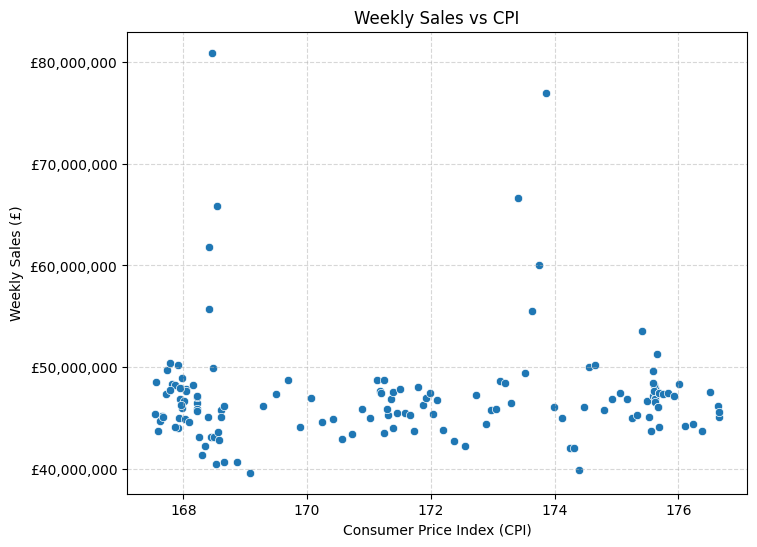

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

plt.figure(figsize=(8,6))
sns.scatterplot(data=weekly_total, x="CPI", y="Weekly_Sales")

# Format Y-axis as currency (£)
formatter = mtick.StrMethodFormatter('£{x:,.0f}')
plt.gca().yaxis.set_major_formatter(formatter)

plt.title("Weekly Sales vs CPI")
plt.xlabel("Consumer Price Index (CPI)")
plt.ylabel("Weekly Sales (£)")

plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

The scatter plot of Weekly Sales against CPI suggests that the relationship between the two variables is weak and non-linear. Sales values are distributed across multiple CPI levels, with visible clustering patterns that may reflect different economic periods within the dataset. This indicates that CPI may have some influence on sales, but it is unlikely to act as a strong standalone predictor. Instead, its effect is likely to interact with other variables in the forecasting model.

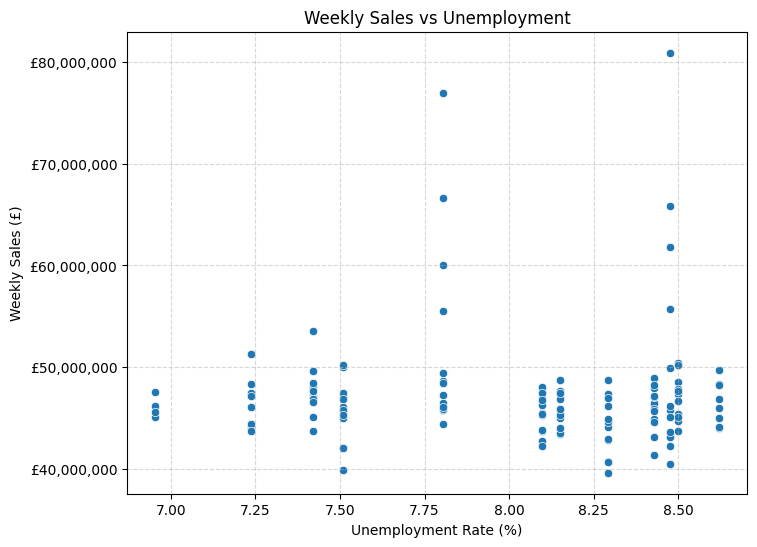

In [13]:
import seaborn as sns
import matplotlib.ticker as mtick

plt.figure(figsize=(8,6))
sns.scatterplot(data=weekly_total, x="Unemployment", y="Weekly_Sales")

# Format Y-axis as currency (£)
formatter = mtick.StrMethodFormatter('£{x:,.0f}')
plt.gca().yaxis.set_major_formatter(formatter)

plt.title("Weekly Sales vs Unemployment")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Weekly Sales (£)")

plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

The relationship between weekly sales and unemployment appears weak, with a slight negative trend indicating that higher unemployment levels may be associated with reduced sales. However, the scattered distribution suggests that unemployment is not a strong standalone predictor and likely interacts with other variables in influencing sales performance.

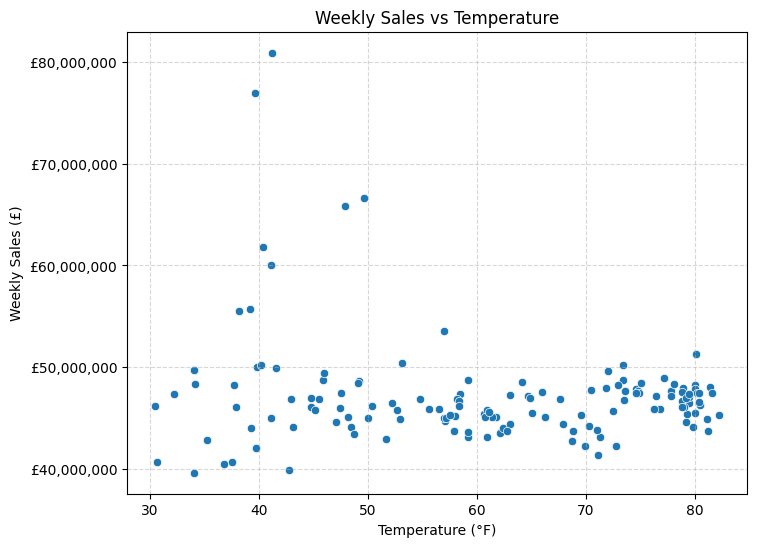

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

plt.figure(figsize=(8,6))
sns.scatterplot(data=weekly_total, x="Temperature", y="Weekly_Sales")

# Format Y-axis as currency (£)
formatter = mtick.StrMethodFormatter('£{x:,.0f}')
plt.gca().yaxis.set_major_formatter(formatter)

plt.title("Weekly Sales vs Temperature")
plt.xlabel("Temperature (°F)")  # or °C depending on dataset
plt.ylabel("Weekly Sales (£)")

plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

The scatter plot between weekly sales and temperature shows no clear relationship, with sales values widely dispersed across all temperature ranges. This indicates that temperature does not have a significant direct impact on sales and is unlikely to be a strong predictor in the forecasting model.

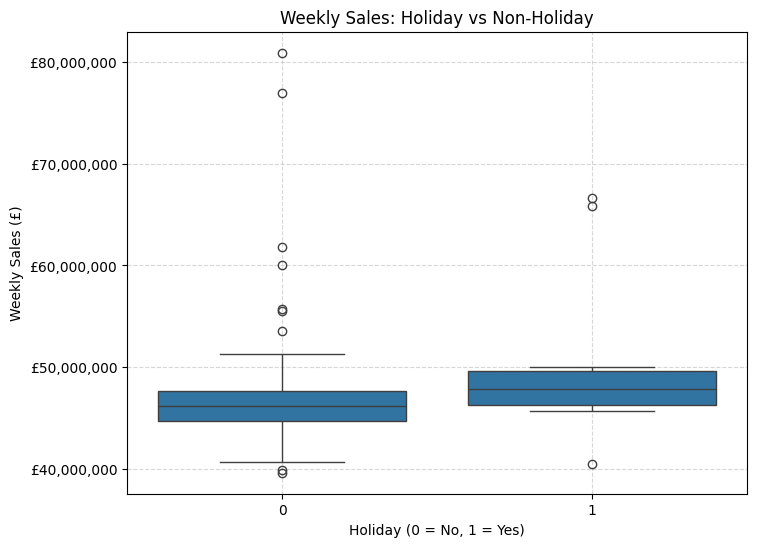

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

plt.figure(figsize=(8,6))

sns.boxplot(data=weekly_total, x="Holiday_Flag", y="Weekly_Sales")

# Format Y-axis as currency (£)
formatter = mtick.StrMethodFormatter('£{x:,.0f}')
plt.gca().yaxis.set_major_formatter(formatter)

plt.title("Weekly Sales: Holiday vs Non-Holiday")
plt.xlabel("Holiday (0 = No, 1 = Yes)")
plt.ylabel("Weekly Sales (£)")

plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

The boxplot shows that weekly sales during holiday periods tend to have a slightly higher median and greater variability compared to non-holiday weeks. 

However, there is significant overlap between the distributions, indicating that while holidays contribute to increased demand, they are not the sole driver of high sales periods. Other factors, such as seasonal trends and time-based effects, also play an important role.

This suggests that the Holiday_Flag variable is useful but should be considered alongside additional features in the forecasting model.

#### 6.2 Sales Trend over time 

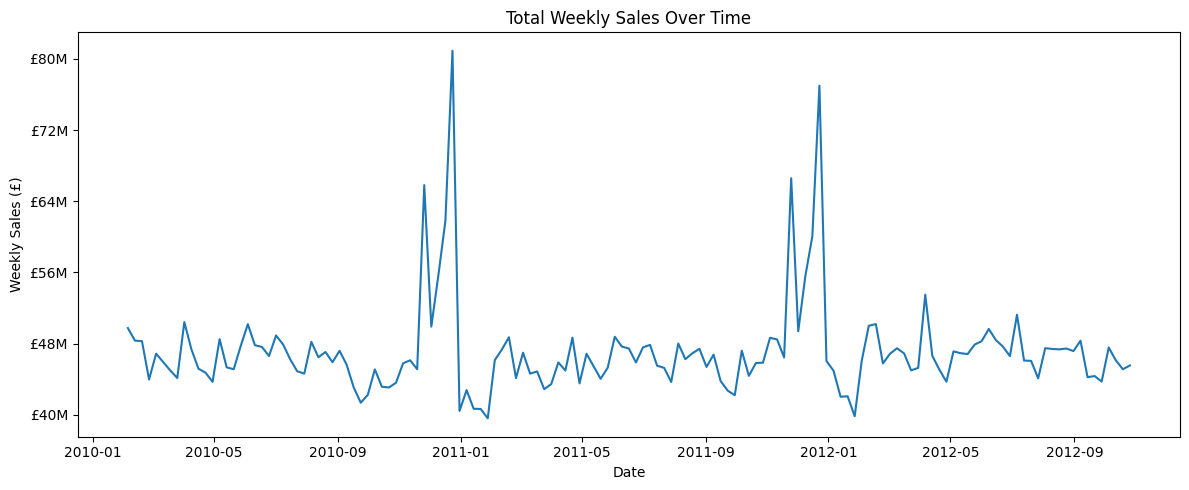

In [16]:
import matplotlib.ticker as ticker

plt.figure(figsize=(12,5))
plt.plot(weekly_total['Date'], weekly_total['Weekly_Sales'])

plt.title("Total Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Weekly Sales (£)")

ax = plt.gca()

# Format to £ millions
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'£{x/1e6:.0f}M')
)

# OPTIONAL: cleaner tick spacing (THIS is the bit you asked about)
ax.yaxis.set_major_locator(ticker.MaxNLocator(6))

plt.tight_layout()
plt.show()

The time series plot shows that weekly sales fluctuate over time with noticeable peaks, particularly towards the end of each year. These spikes suggest that sales are strongly influenced by recurring seasonal demand patterns.

Sales tend to increase significantly between October and December, followed by a sharp decline in January. This reflects typical retail behaviour during holiday periods and post-holiday slowdowns.

#### 6.3 Rolling Average Trend

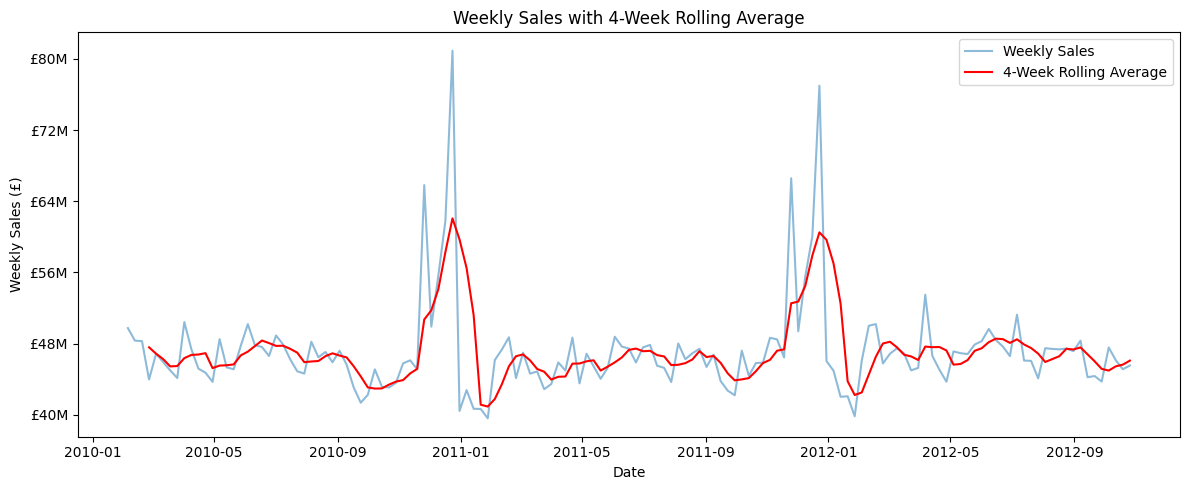

In [17]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

weekly_total['Rolling_4wk'] = weekly_total['Weekly_Sales'].rolling(window=4).mean()

plt.figure(figsize=(12,5))
plt.plot(weekly_total['Date'], weekly_total['Weekly_Sales'], alpha=0.5, label='Weekly Sales')
plt.plot(weekly_total['Date'], weekly_total['Rolling_4wk'], color='red', label='4-Week Rolling Average')

plt.title("Weekly Sales with 4-Week Rolling Average")
plt.xlabel("Date")
plt.ylabel("Weekly Sales (£)")

plt.legend()

ax = plt.gca()
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'£{x/1e6:.0f}M')
)
ax.yaxis.set_major_locator(ticker.MaxNLocator(6))

plt.tight_layout()
plt.show()

The 4-week rolling average smooths short-term fluctuations and highlights the underlying trend in weekly sales. It confirms that the series is generally stable over time but exhibits clear seasonal peaks toward the end of each year, followed by a sharp decline in January.

#### 6.4 Monthly seasonality

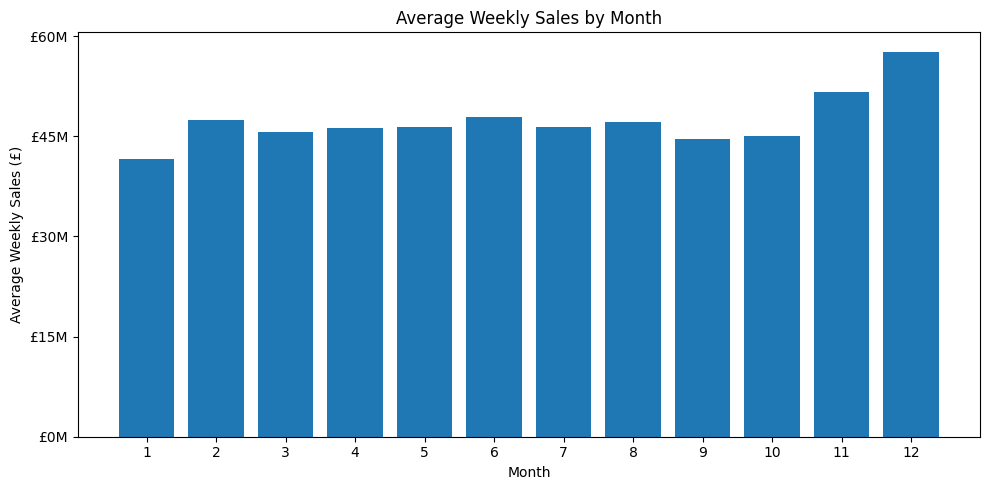

In [18]:
import matplotlib.ticker as ticker

# Create Month column from Date
weekly_total['Month'] = weekly_total['Date'].dt.month

# Calculate average weekly sales by month
monthly_avg = (
    weekly_total
    .groupby('Month', as_index=False)['Weekly_Sales']
    .mean()
)

# Plot monthly seasonality
plt.figure(figsize=(10,5))
plt.bar(monthly_avg['Month'], monthly_avg['Weekly_Sales'])

plt.title("Average Weekly Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Weekly Sales (£)")
plt.xticks(range(1,13))

ax = plt.gca()
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'£{x/1e6:.0f}M')
)
ax.yaxis.set_major_locator(ticker.MaxNLocator(6))

plt.tight_layout()
plt.show()

The monthly aggregation highlights clear seasonal patterns in weekly sales. Sales peak in December, likely due to holiday demand, followed by a noticeable decline in January.

This consistent seasonal trend supports the inclusion of the Month variable as an important predictor in the forecasting model.

#### 6.5 Correlation Matrix 

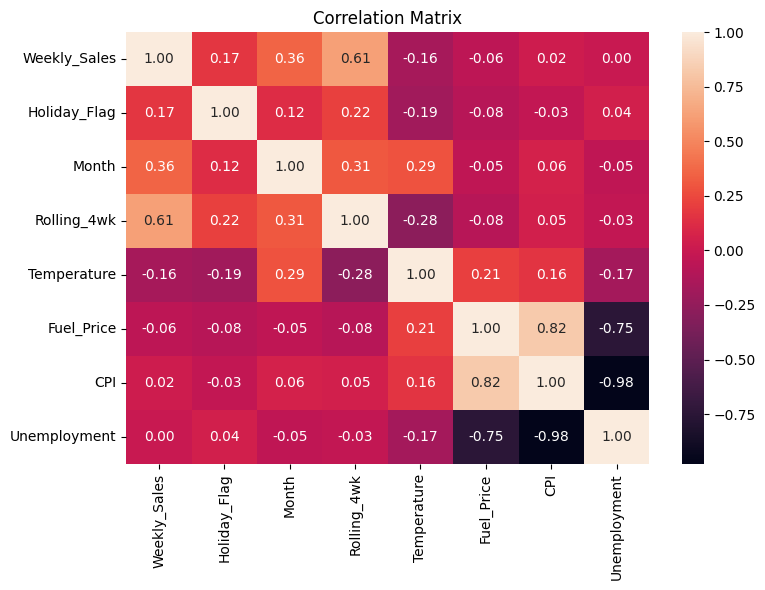

In [19]:
corr = weekly_total[['Weekly_Sales','Holiday_Flag','Month','Rolling_4wk','Temperature','Fuel_Price','CPI','Unemployment']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

The correlation matrix shows that the 4-week rolling average has the strongest relationship with weekly sales (0.61), indicating that recent sales trends are highly predictive.

The Month variable also shows a moderate positive correlation (0.37), supporting the presence of seasonal patterns observed earlier.

In contrast, economic variables such as CPI, Fuel Price, and Unemployment exhibit weak correlations with sales, suggesting that they are not strong standalone predictors.

Overall, this analysis indicates that sales are influenced by a combination of temporal patterns rather than individual external factors, supporting the use of more advanced models such as Random Forest.

## Conclusion


The exploratory data analysis reveals that weekly sales are highly variable and are not strongly driven by any single factor. Holiday periods are associated with higher and more volatile sales, indicating increased demand during these times. Economic variables such as CPI and unemployment show weak and non-linear relationships with sales, while temperature demonstrates little to no direct influence. The presence of clustering and dispersed patterns across the visualisations suggests that the relationships between variables are complex and not purely linear. These findings indicate that traditional linear models may struggle to capture the underlying patterns in the data. Therefore, more flexible machine learning approaches, such as Random Forest, are appropriate for modelling and forecasting weekly sales.

# 7. Linearity vs Non-Linearity Analysis

non linear baseline model 

In [20]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(
    max_depth=5,        # prevents overfitting
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

In [21]:
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))

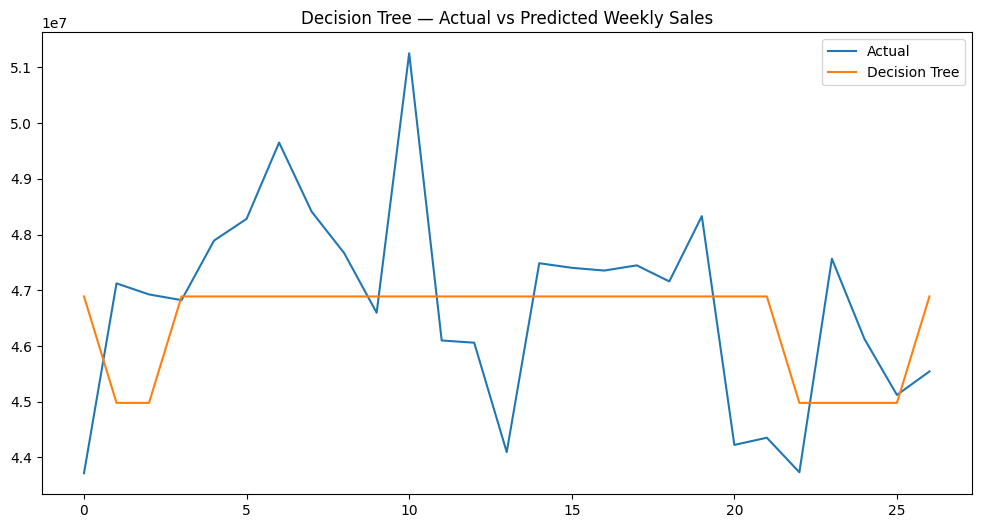

In [22]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred_dt, label="Decision Tree")
plt.legend()
plt.title("Decision Tree — Actual vs Predicted Weekly Sales")
plt.show()

The Decision Tree regressor was used as a baseline non-linear model because it can capture complex relationships through threshold-based splits without assuming a linear form. As shown in the figure, the model produces step-like, piecewise-constant predictions, reflecting how observations within the same region receive identical values. While the tree captures overall sales levels, it does not reproduce short-term fluctuations or extreme values due to its discrete structure. Nevertheless, it provides an interpretable reference point for evaluating more advanced non-linear models such as Random Forest and Gradient Boosting.

non linear models advanced 

Random Forest model 

In [23]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R²:", r2_rf)

Random Forest Results
MAE: 1377804.981807416
RMSE: 1729881.7159859678
R²: 0.03957975268341085


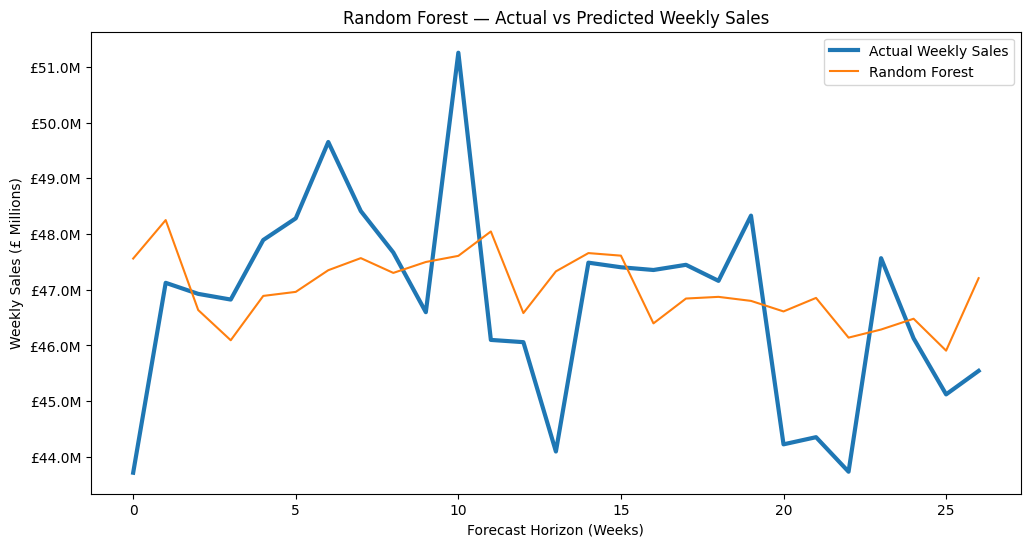

In [24]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure(figsize=(12,6))

# Actual vs Prediction
plt.plot(y_test.values, label="Actual Weekly Sales", linewidth=3)
plt.plot(y_pred_rf, label="Random Forest")

# Titles and labels
plt.title("Random Forest — Actual vs Predicted Weekly Sales")
plt.xlabel("Forecast Horizon (Weeks)")
plt.ylabel("Weekly Sales (£ Millions)")

# Format y-axis to millions (removes 1e7)
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'£{x/1e6:.1f}M')
)

plt.legend()
plt.show()

The Random Forest regressor was selected as a non-linear ensemble method capable of modelling complex relationships between input variables and weekly sales. Unlike linear models, Random Forest does not assume a linear relationship and can capture interactions, threshold effects, and non-monotonic patterns commonly observed in retail demand data.

As shown in the figure, the Random Forest predictions broadly follow the overall trend of the actual weekly sales, indicating that the model successfully captures medium-term variations in demand. The model responds to directional changes and reproduces general fluctuations across the time horizon, demonstrating its ability to learn underlying patterns from the training data.

However, the predicted series appears noticeably smoother than the actual observations. Extreme peaks and troughs — particularly the large spike around period 10 and sharp declines later in the series — are not fully reproduced. This behaviour is characteristic of ensemble tree methods, which average predictions across many decision trees, reducing variance but also dampening short-term volatility. While this smoothing improves stability and robustness to noise, it can limit responsiveness to sudden demand shocks such as promotional events, holidays, or external disruptions.

From a forecasting perspective, the model provides reliable baseline predictions and is well-suited to strategic planning scenarios where stable demand estimates are preferred over highly reactive forecasts. However, for operational decision-making requiring precise anticipation of sharp fluctuations, additional models or feature engineering may be necessary.
Overall, the Random Forest model demonstrates strong capability in modelling non-linear relationships and capturing the general structure of weekly sales, but its tendency to smooth extreme variations highlights a trade-off between stability and sensitivity to short-term changes.


GBM Graident Booster 

In [25]:
from sklearn.ensemble import GradientBoostingRegressor

gbr_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbr_model.fit(X_train, y_train)

y_pred_gbr = gbr_model.predict(X_test)

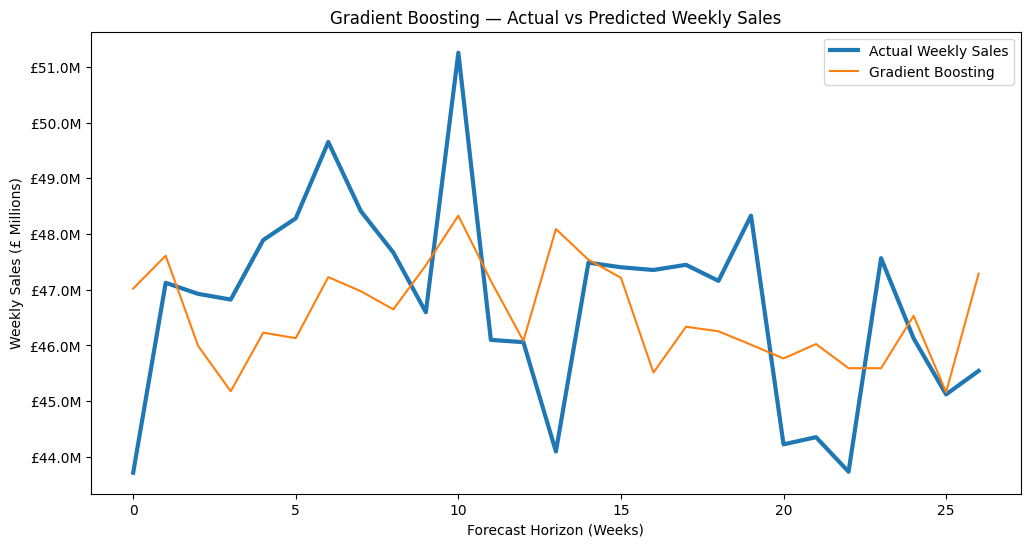

In [26]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure(figsize=(12,6))

# Actual vs Prediction
plt.plot(y_test.values, label="Actual Weekly Sales", linewidth=3)
plt.plot(y_pred_gbr, label="Gradient Boosting")

# Titles and labels
plt.title("Gradient Boosting — Actual vs Predicted Weekly Sales")
plt.xlabel("Forecast Horizon (Weeks)")
plt.ylabel("Weekly Sales (£ Millions)")

# Format y-axis to £ millions (removes 1e7 notation)
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'£{x/1e6:.1f}M')
)

plt.legend()
plt.show()

Gradient Boosting regressor is selected due to its ability to capture complex relationships in retail demand data through sequential error correction. Unlike bagging methods such as Random Forest, the Gradient boosting regressor builds trees iteratively, each new tree trained to minimise the residual errors of the previous ensemble. This means the model can detect subtle patterns, local trends and non-linear interactions between predictors that are not well represented by linear approaches. 

As illustrated in the figure, the Gradient Boosting predictions closely follow the overall trajectory of the actual weekly sales series. The model successfully captures medium-term fluctuations and directional changes, particularly around periods of rising demand and subsequent declines. Compared with simpler models, the predicted series demonstrates responsiveness to shifts in the underlying pattern rather than producing a constant or purely smoothed estimate.

One problem with gradient boosting in this case the predictions remain smoother than the observed data and extreme peaks are not fully reproduced an example of this is the pronounced spike around period 10 and sharp drop shortly after only partially captured this behavour is expected gradient boosting balances biast and variance by avoiding overfitting to noise or isolated events  In retail forecasting contexts, such smoothing can be advantageous because it produces stable predictions that are less sensitive to irregular shocks such as short-term promotions or anomalies.

Overall, the model achieves a strong compromise between flexibility and stability. It is sufficiently expressive to model non-linear demand dynamics while maintaining robust generalisation across the time horizon. This makes Gradient Boosting particularly suitable for strategic forecasting tasks where reliable trend estimation is more valuable than an exact replication of extreme fluctuations.

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))

print("GBR MAE:", mae_gbr)
print("GBR RMSE:", rmse_gbr)

GBR MAE: 1464917.4061489552
GBR RMSE: 1763834.7340671094


Support Vector Regression 

In [28]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor

svr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(
        kernel="rbf",
        C=1000,        # MUCH stronger
        gamma=0.01,    # Controls flexibility
        epsilon=0.1
    ))
])

svr_model = TransformedTargetRegressor(
    regressor=svr_pipeline,
    transformer=StandardScaler()
)

svr_model.fit(X_train, y_train)

y_pred_svr = svr_model.predict(X_test)

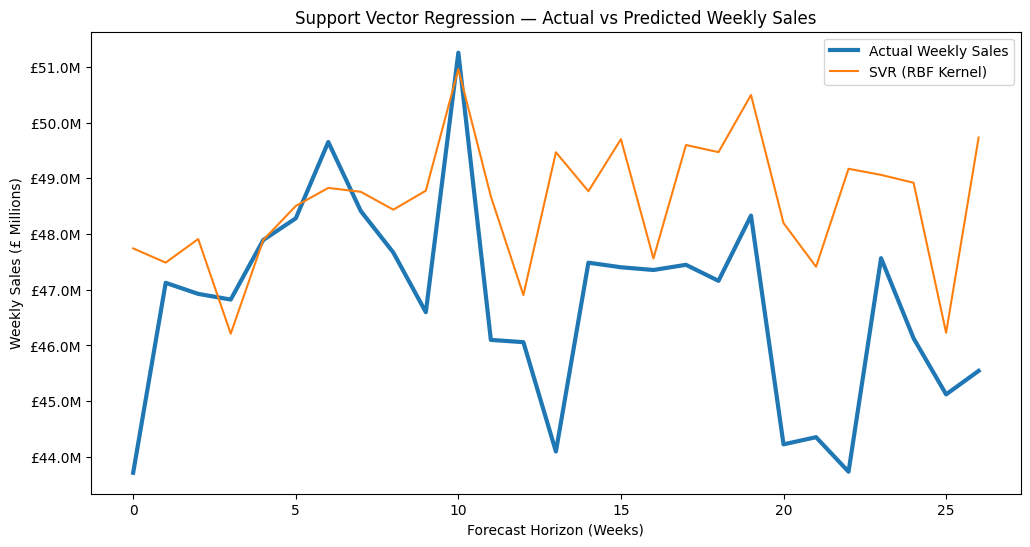

In [29]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure(figsize=(12,6))

# Actual vs Prediction
plt.plot(y_test.values, label="Actual Weekly Sales", linewidth=3)
plt.plot(y_pred_svr, label="SVR (RBF Kernel)")

# Titles and labels
plt.title("Support Vector Regression — Actual vs Predicted Weekly Sales")
plt.xlabel("Forecast Horizon (Weeks)")
plt.ylabel("Weekly Sales (£ Millions)")

# Format y-axis to £ millions (removes scientific notation)
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'£{x/1e6:.1f}M')
)

plt.legend()
plt.show()

As shown in the graph, SVR does not closely follow the actual series pattern. The prediction fluctuates significantly and is often above or below the real values, especially during sharp rises and falls. It matches some peaks but misses the overall trend. 


In [30]:
mae_svr = mean_absolute_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
r2_svr = r2_score(y_test, y_pred_svr)

MLP Regressor 

In [31]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor

mlp_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(100, 50),
        activation='relu',
        solver='adam',
        max_iter=3000,
        early_stopping=True,
        random_state=42
    ))
])

mlp_model = TransformedTargetRegressor(
    regressor=mlp_pipeline,
    transformer=StandardScaler()
)

mlp_model.fit(X_train, y_train)

y_pred_mlp = mlp_model.predict(X_test)

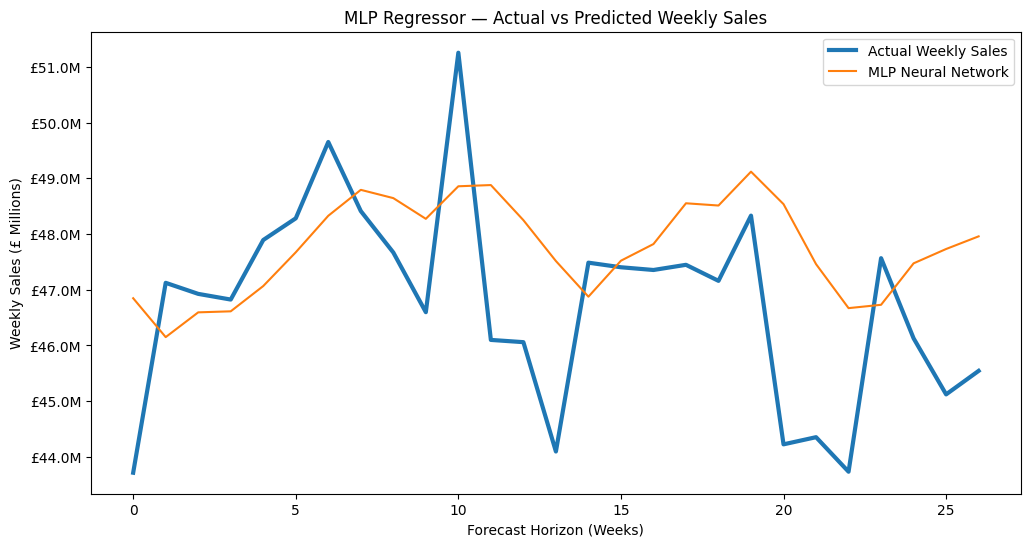

In [32]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure(figsize=(12,6))

# Actual vs Prediction
plt.plot(y_test.values, label="Actual Weekly Sales", linewidth=3)
plt.plot(y_pred_mlp, label="MLP Neural Network")

# Titles and labels
plt.title("MLP Regressor — Actual vs Predicted Weekly Sales")
plt.xlabel("Forecast Horizon (Weeks)")
plt.ylabel("Weekly Sales (£ Millions)")

# Format y-axis to £ millions (removes scientific notation)
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'£{x/1e6:.1f}M')
)

plt.legend()
plt.show()

The MLP Regressor follows the general trend of the actual sales series but produces smoother predictions. Overall, it captures trends and some changes in demand but mirrors sharp spikes and sudden drops. It is reasonably accurate for the overall pattern, but less precise during periods of rapid fluctuation.


In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_mlp = mean_absolute_error(y_test, y_pred_mlp)
rmse_mlp = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
r2_mlp = r2_score(y_test, y_pred_mlp)

print("MLP Neural Network Results")
print(f"MAE: £{mae_mlp/1e6:.2f}M")
print(f"RMSE: £{rmse_mlp/1e6:.2f}M")
print(f"R²: {r2_mlp:.3f}")

MLP Neural Network Results
MAE: £1.60M
RMSE: £1.96M
R²: -0.234


Model Comparison graph 

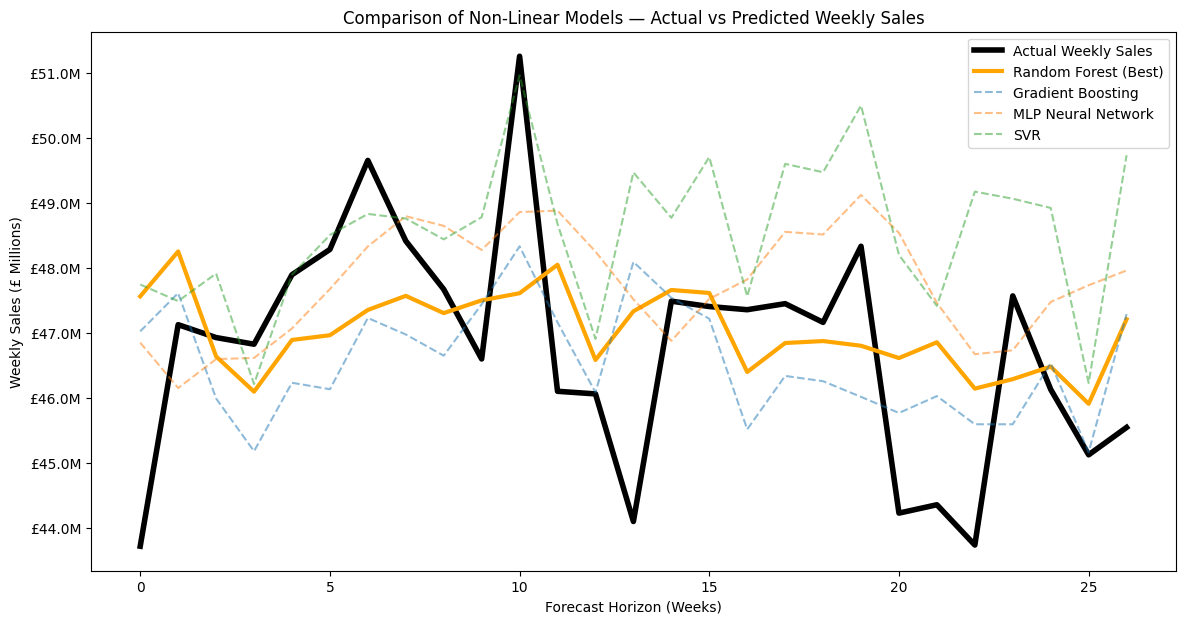

In [34]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure(figsize=(14,7))

# =========================
# MOST PROMINENT — Actual
# =========================
plt.plot(
    y_test.values,
    label="Actual Weekly Sales",
    linewidth=4,
    color="black"
)

# =========================
# SECOND — BEST MODEL (RF)
# =========================
plt.plot(
    y_pred_rf,
    label="Random Forest (Best)",
    linewidth=3,
    color="orange"
)

# =========================
# LESS PROMINENT MODELS
# =========================
plt.plot(y_pred_gbr, label="Gradient Boosting", alpha=0.5, linestyle="--")
plt.plot(y_pred_mlp, label="MLP Neural Network", alpha=0.5, linestyle="--")
plt.plot(y_pred_svr, label="SVR", alpha=0.5, linestyle="--")

# Titles and labels
plt.title("Comparison of Non-Linear Models — Actual vs Predicted Weekly Sales")
plt.xlabel("Forecast Horizon (Weeks)")
plt.ylabel("Weekly Sales (£ Millions)")

# Format y-axis to £ millions
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'£{x/1e6:.1f}M')
)

plt.legend()
plt.show()


The random forrest creates the best overall trend of the data and produces highly stable predictions throughout the forecast horizon. By aggrigrating the outputs of multiple decision trees. The random forrest model reduces variance and mitigates the impact of noise and outliers. Even though this ensemble averaging introduces some smoothing the prediction remain constantly close to the weekly sales. This results in smaller overall sales. 
Gradient boosting demonstration to the short term changes by sequentianlly correcting residual errors. This means its able to respond to local variations more closely than the random forest model in certain ereas but the model also exhibits a tendency to overfit minor fluctuations leading to a less stable predictions and slightly larger deviation from the true vales over the full time horizon 
The MLP neural network produces predictions that follow the broad structure of the series and captures some intermediate fluctuations reflecting its ability to model complex nonlinear relationships. Unfortunately, the network shows noticeable smoothing and fails to reduce abrupt changes in demand. This shows that the model has not fully converged to an optimal representation of the underlying process, and additional tuning 
The SVR model produces uneven predictions that often move away from the real sales values. It occasionally aligns with the extreme values it often predicts values that are way to high or too low. This inconsistent behavior shows the model does not learn the underlying pattern well as it is very sensitive to how its settings are configured. As a result, it can't be a reliable choice for the Walmart forecasting task 
The Random Forrest model performs the best overall during the evaluation period. Its predictions stay close to the real sales data, it avoids big mistakes, and is the most reliable when the demand changes frequently. Although it doesn't capture extreme peaks, it is consistently accurate, making it the strongest choice for real-world forecasting where dependable results matter more than reacting to every small change 
From a business point of view, this stability is very useful for planning and decision-making. Reliable forecasts help companies avoid overreacting to short-term ups and downs while still showing the true pattern of customer demand. This leads to better decisions about how much stock to hold and how to allocate staff and other resources.


Metric comparison table 

In [35]:
print("Non-Linear Model Performance (Error in £ Millions)\n")

print(f"Random Forest      — MAE: £{mae_rf/1e6:.2f}M   RMSE: £{rmse_rf/1e6:.2f}M")
print(f"Gradient Boosting  — MAE: £{mae_gbr/1e6:.2f}M   RMSE: £{rmse_gbr/1e6:.2f}M")
print(f"MLP Neural Network — MAE: £{mae_mlp/1e6:.2f}M   RMSE: £{rmse_mlp/1e6:.2f}M")
print(f"SVR (RBF Kernel)   — MAE: £{mae_svr/1e6:.2f}M   RMSE: £{rmse_svr/1e6:.2f}M")

Non-Linear Model Performance (Error in £ Millions)

Random Forest      — MAE: £1.38M   RMSE: £1.73M
Gradient Boosting  — MAE: £1.46M   RMSE: £1.76M
MLP Neural Network — MAE: £1.60M   RMSE: £1.96M
SVR (RBF Kernel)   — MAE: £1.92M   RMSE: £2.47M


In [36]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_rf  = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
rmse_mlp = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))

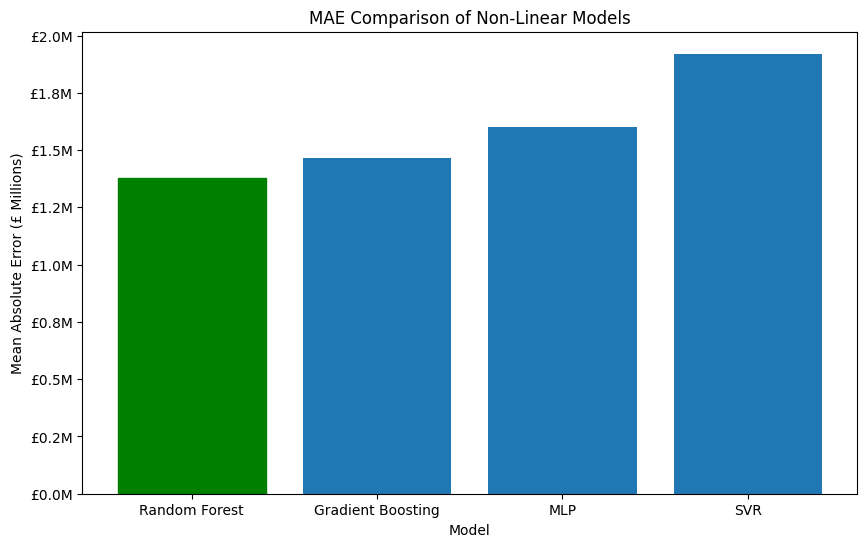

In [37]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Model names
models = ["Random Forest", "Gradient Boosting", "MLP", "SVR"]

# MAE values converted to £ millions
mae_scores_millions = [
    mae_rf / 1e6,
    mae_gbr / 1e6,
    mae_mlp / 1e6,
    mae_svr / 1e6
]

plt.figure(figsize=(10,6))

bars = plt.bar(models, mae_scores_millions)

# Highlight best (lowest MAE)
best_index = mae_scores_millions.index(min(mae_scores_millions))
bars[best_index].set_color("green")

plt.title("MAE Comparison of Non-Linear Models")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error (£ Millions)")

# Format axis with £
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'£{x:.1f}M')
)

plt.show()

This bar chart shows the Random Forest model has the lowest MAE, meaning its predictions are the closest to the actual sales on average,therefore it is the most accurate model.


RMSE Comparison Graph 

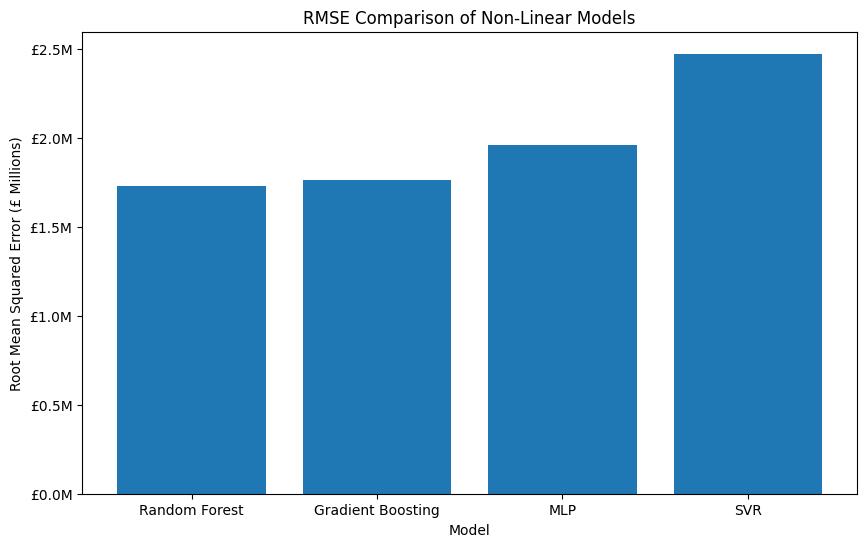

In [38]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

models = ["Random Forest", "Gradient Boosting", "MLP", "SVR"]

# Convert RMSE to £ millions
rmse_scores_millions = [
    rmse_rf / 1e6,
    rmse_gbr / 1e6,
    rmse_mlp / 1e6,
    rmse_svr / 1e6
]

plt.figure(figsize=(10,6))
plt.bar(models, rmse_scores_millions)

plt.title("RMSE Comparison of Non-Linear Models")
plt.ylabel("Root Mean Squared Error (£ Millions)")
plt.xlabel("Model")

# Format y-axis with £ symbol
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'£{x:.1f}M')
)

plt.show()

Random forest also has the lowest RMSE. This means it makes the smallest large errors and can handle extreme variation better than any other model.


## 8. Model Development

In [39]:
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")

In [40]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Week"] = df["Date"].dt.isocalendar().week.astype(int)
df["Day"] = df["Date"].dt.day

In [41]:
df = df.drop("Date", axis=1)

In [42]:
X = df.drop("Weekly_Sales", axis=1)
y = df["Weekly_Sales"]

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [44]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [45]:
y_pred_rf = rf_model.predict(X_test)

In [46]:
# Calculate residuals (prediction errors)
residuals_rf = y_test - y_pred_rf

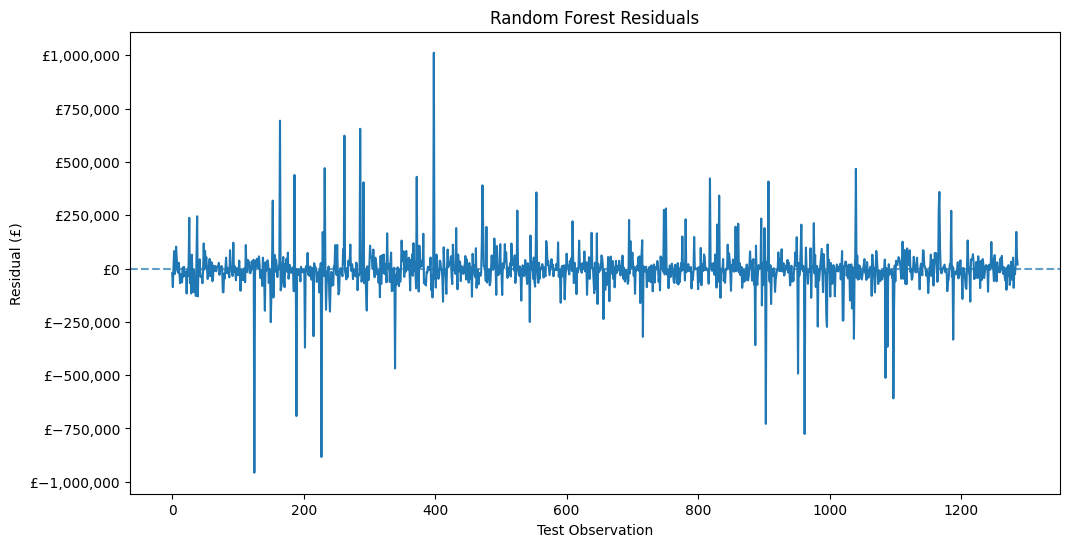

In [47]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.figure(figsize=(12,6))
plt.plot(residuals_rf.values)
plt.axhline(0, linestyle="--", alpha=0.7)

formatter = mtick.StrMethodFormatter('£{x:,.0f}')
plt.gca().yaxis.set_major_formatter(formatter)

plt.title("Random Forest Residuals")
plt.xlabel("Test Observation")
plt.ylabel("Residual (£)")

plt.show()

The residual plot illustrates the prediction errors of the Random Forest model, calculated as the difference between actual and predicted weekly sales. Ideally, residuals should be randomly distributed around zero, indicating that the model does not consistently overestimate or underestimate values. In this case, most residuals are clustered near the zero line, suggesting that the model generally produces accurate predictions for typical sales levels. The lack of a visible trend or pattern indicates that the model does not suffer from systematic bias. However, several large positive and negative spikes are present, representing weeks where prediction errors are significantly higher. These deviations likely correspond to unusual demand patterns or external factors not fully captured by the model. Overall, the residual distribution indicates that the model performs reliably for normal sales behaviour but is less accurate during periods of extreme variation.

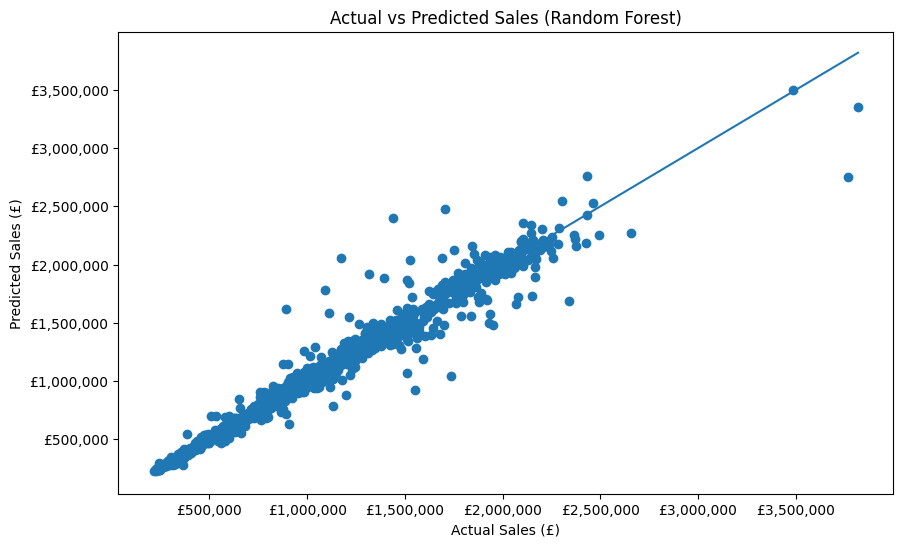

In [48]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred_rf)

# Diagonal reference line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])

# Format axis as currency (£)
formatter = mtick.StrMethodFormatter('£{x:,.0f}')
plt.gca().xaxis.set_major_formatter(formatter)
plt.gca().yaxis.set_major_formatter(formatter)

plt.title("Actual vs Predicted Sales (Random Forest)")
plt.xlabel("Actual Sales (£)")
plt.ylabel("Predicted Sales (£)")

plt.show()

Actual vs Predicted Sales Analysis

The Actual vs Predicted plot illustrates the relationship between the observed weekly sales and the values predicted by the Random Forest model. The majority of data points are closely aligned along the diagonal reference line, indicating a strong agreement between predicted and actual values. This suggests that the model is effective in capturing the overall sales patterns within the dataset.

However, some dispersion is visible, particularly at higher sales values, where predictions deviate further from the actual values. This indicates that the model is less accurate when forecasting extreme sales levels, likely due to the increased variability during peak demand periods such as holidays or promotional events.

Overall, the plot demonstrates that the Random Forest model provides a good level of predictive accuracy, with most errors being relatively small, while highlighting some limitations in handling high-value outliers.

5. Ethical, Privacy and Security Evaluation 

The deployment of predictive analytics in this retail environment must be evaluated by considering both the technical systems involved and the accuracy of forecasting. Machine learning systems impact operational decisions, labour allocation, procurement strategies and resource allocation, this means within organisational structures such as forecasting models carry ethical, privacy and security implications (Floridi et al.,2018). Despite the Walmart dataset being used in this project is publicly available and anonymised, if this was a real-world implementation of a similar system it would involve integrating enterprise data ecosystems. This means governance mechanisms such as AI ethics principles, data protection standards and information security frameworks must be aligned with for responsible deployment. 

5.1 Ethical Considerations 

5.1.1 Automation Bias and Managerial Accountability 

Retail forecasting systems increasingly dictate workforce scheduling and investory allocation, however over reliance on algorithmic predications can cause automation bias, which can cause over trust in the system outputs from the human decision makers and reduce critical oversight (Parasuraman and Riley, 1997). If the demand forecasts are used for staffing reductions during periods of predicted low demand, workers in flexible roles are likely to experience income volatility. When predictive models are treated as objective truth instead of estimates raising concerns about fairness and distributive justice (Mittelstadt et al., 2016). Ethical AI frameworks highlight how crucial it is for human oversight, transparency and contestability (High-Level Expert Group on AI, 2019). This means that forecasting outputs should inform managerial judgment rather than replace it. 

Mitigation strategies include: 

Maintaining human review mechanisms in workforce planning decisions. 

Incorporating forecast confidence intervals rather than single-point predictions. 

Auditing scheduling outcomes to detect disproportionate impacts. 

Embedding explainability practices to ensure transparency in model outputs (Rudin, 2019). 

By using the governance safeguards, operational efficiency will be preserved whilst reducing the risk of unfair labour impacts.  

5.1.2 Structural Bias and Market Concentration 

Even though this dataset doesn’t contain demographic information, structural inequalities can still be reinforced by predictive systems. An example for in this context would be if forecasts prioritise consistently higher-performing stores or departments, acquisitional decisions may favour dominant suppliers which reinforces existing market concentration patterns (O’Neil, 2016). This event aligns with issues involving feedback loops in algorithmic systems in which historical patterns are reoccurring and amplified (Barocas and Selbst, 2016). In retail forecasting contexts it could lead to reduced opportunities for smaller suppliers and emerging product categories. 

Mitigation measures should include: 

Periodic review of procurement patterns influenced by forecasting systems. 

Scenario-based planning rather than deterministic automation. 

Institutional policies supporting supplier diversification. 

Therefore, ethical forecasting practice requires understanding of systematic effectsof predictive performance. 

5.2 Privacy and Data Governance 

Even though the dataset analysed here doesn’t contain any personally identifiable information, transactional, loyalty and demographic data are frequently integrated into real world forecasting infrastructures. The accumulation of these databases increases the reidentification risk, especially when cross-referenced with external data sources (Narayanan and Shmatikov, 2008). 

Organisations must abide by data minimisation, purpose limitation and storage limitation standards in accordance with General Data Protection Regulation (GDPR) (European Parliament and Council, 2016). Combined store forecasts may reveal sensitive business information, even when individual data is anonymised, this is because anonymisation only removes personal identifiers, not the business insight contained in the data. 

Beyond legal compliance, privacy governance in predictive systems requires: 

Role-based access controls. 

Data encryption in transit and at rest. 

Differential access privileges for forecasting outputs. 

Clear retention and deletion policies. 

Privacy considerations extend to organisational transparency which is important because stakeholders must understand how organisations predictive outputs influence operational decisions especially when such decisions affect employees or suppliers. 

5.3 Security and Model Integrity 

Forecasting systems are a valuable strategic asset to businesses, this means that if the data is compromised or data settings are altered, it can lead to disruptions and operational failures across inventory systems and supply chains. 

Information security literature emphasises the importance of confidentiality, integrity, and availability (CIA triad) in safeguarding enterprise systems (Whitman and Mattord, 2018). In predictive retail contexts, security risks include: 

Data tampering or unauthorised modification of historical records. 

Model poisoning attacks, where corrupted training data alters predictive behaviour (Biggio and Roli, 2018). 

Insider threats involving privileged access. 

API exploitation or unauthorised extraction of forecasting outputs. 

Mitigation requires multi-layered security controls: 

Secure data storage with encryption protocols. 

Multi-factor authentication for model access. 

Version control and audit logging of model updates. 

Continuous monitoring for anomalous forecast deviations. 

In large scale retail operations, even a small change to forecasting results can lead to significant financial impacts, as a result forecasting systems must be treated as a critical infrastructure within risk management. 

 

5.4 Broader Critical Reflection 

This Evaluation shows that system success can not solely be determined by predictive accuracy and that responsible business intelligence requires the integration of ethical governance, privacy safeguards and robust security architecture. 

Retail forecasting systems operate in complex environments where predictions affect staff work, supplies, and business decisions. Floridi et al. (2018) highlights that ethical AI should follow key principles including beneficence, non-maleficence, autonomy, and justice. 

By embedding human oversight, transparency, data governance, and security safeguards, organisations can make sure that predictive analytics enhances operational efficiency without generating unintended harm. The value of this project therefore lies not only in its technical modelling but in its recognition that machine learning systems must operate within accountable and ethically grounded frameworks. 

 

 

Reference List (UWE Harvard Style with Links) 

Barocas, S. and Selbst, A.D. (2016) ‘Big data’s disparate impact’, California Law Review, 104(3), pp. 671–732. Available at: https://doi.org/10.15779/Z38BG31 (Accessed: 30 January 2026). 

Biggio, B. and Roli, F. (2018) ‘Wild patterns: Ten years after the rise of adversarial machine learning’, Pattern Recognition, 84, pp. 317–331. Available at: https://doi.org/10.1016/j.patcog.2018.07.023 (Accessed: 30 January 2026). 

European Parliament and Council (2016) Regulation (EU) 2016/679 (General Data Protection Regulation). Available at: https://eur-lex.europa.eu/eli/reg/2016/679/oj (Accessed: 30 January 2026). 

Floridi, L. et al. (2018) ‘AI4People—An ethical framework for a good AI society’, Minds and Machines, 28(4), pp. 689–707. Available at: https://doi.org/10.1007/s11023-018-9482-5 (Accessed: 30 January 2026). 

High-Level Expert Group on AI (2019) Ethics Guidelines for Trustworthy AI. European Commission. Available at: https://digital-strategy.ec.europa.eu/en/library/ethics-guidelines-trustworthy-ai (Accessed: 30 January 2026). 

Mittelstadt, B.D. et al. (2016) ‘The ethics of algorithms: Mapping the debate’, Big Data & Society, 3(2). Available at: https://doi.org/10.1177/2053951716679679 (Accessed: 30 January 2026). 

Narayanan, A. and Shmatikov, V. (2008) ‘Robust de-anonymization of large sparse datasets’, IEEE Symposium on Security and Privacy, pp. 111–125. Available at: https://doi.org/10.1109/SP.2008.33 (Accessed: 30 January 2026). 

O’Neil, C. (2016) Weapons of Math Destruction: How Big Data Increases Inequality and Threatens Democracy. New York: Crown. Available at: https://www.penguinrandomhouse.com/books/530003/weapons-of-math-destruction-by-cathy-oneil/ (Accessed: 30 January 2026). 

Parasuraman, R. and Riley, V. (1997) ‘Humans and automation: Use, misuse, disuse, abuse’, Human Factors, 39(2), pp. 230–253. Available at: https://doi.org/10.1518/001872097778543886 (Accessed: 30 January 2026). 

Rudin, C. (2019) ‘Stop explaining black box machine learning models for high stakes decisions and use interpretable models instead’, Nature Machine Intelligence, 1(5), pp. 206–215. Available at: https://doi.org/10.1038/s42256-019-0048-x (Accessed: 30 January 2026). 

Whitman, M.E. and Mattord, H.J. (2018) Principles of Information Security. 6th edn. Boston: Cengage Learning. Available at: https://www.cengage.uk/c/principles-of-information-security-6e-whitman/ (Accessed: 30 January 2026). 

## 9. Conclusion